In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vivmankar/asian-vs-african-elephant-image-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 51.8M/51.8M [00:03<00:00, 14.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1):
['dataset']


In [ ]:
import os

# Update path to match the 'dataset' directory in the elephant dataset
data_path = os.path.join(path, 'dataset')

# List subdirectories (usually 'train' and 'test' classes)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['test', 'train']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/vivmankar/asian-vs-african-elephant-image-classification/versions/1/dataset) ---
Found 1028 images. Displaying 6 sample images:


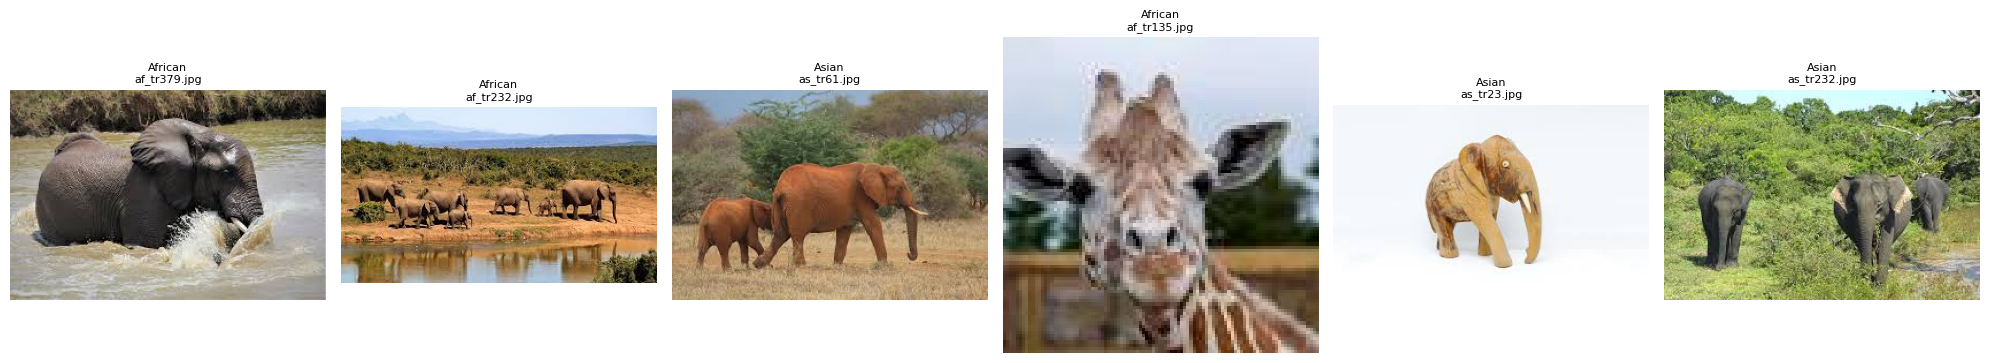

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent folder) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct 'dataset' path
data_path = os.path.join(path, 'dataset')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import tensorflow as tf

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
    print(f'Found GPU at: {device_name}')

# Display GPU details
!nvidia-smi

GPU device not found. Please enable GPU in Notebook Settings.
/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, applications, optimizers

# Data configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    os.path.join(data_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Build VGG Model
with tf.device('/device:GPU:0'):
    base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base layers

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model.summary()

Found 672 images belonging to 2 classes.
Found 168 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Training the model
print("Starting training...")
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator,
        verbose=1
    )
print("Training completed.")

Starting training...
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 524s 25s/step - accuracy: 0.5372 - loss: 0.8360 - val_accuracy: 0.5060 - val_loss: 0.7521
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 520s 25s/step - accuracy: 0.5640 - loss: 0.6979 - val_accuracy: 0.5833 - val_loss: 0.6755
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 520s 25s/step - accuracy: 0.6622 - loss: 0.6330 - val_accuracy: 0.5595 - val_loss: 0.6962
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 520s 25s/step - accuracy: 0.6518 - loss: 0.6251 - val_accuracy: 0.5476 - val_loss: 0.7104
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 519s 25s/step - accuracy: 0.6488 - loss: 0.6234 - val_accuracy: 0.6131 - val_loss: 0.6701
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 525s 25s/step - accuracy: 0.6726 - loss: 0.6083 - val_accuracy: 0.5595 - val_loss: 0.6938
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 521s 25s/step - accuracy: 0.6771 - loss: 0.5947 - val_accuracy: 0.5595 - val_loss: 0.7170
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 581s 28s/step - accuracy: 0.7113 - loss: 0.58

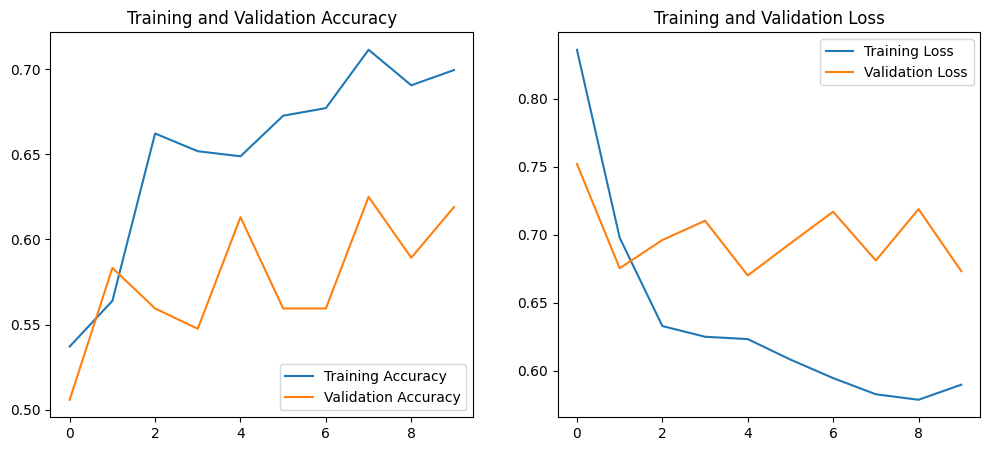

In [ ]:
import matplotlib.pyplot as plt

# Summarize history for accuracy and loss
def plot_training_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_training_results(history)